# Sincronización Multimodal, Resampling, Interpolación y Normalización
### Aplicado al dataset FatigueSet usando la librería `fatigueset`

---

## Tabla de contenidos
1. [Setup](#setup)
2. [Sincronización multimodal](#sync) — El problema de los relojes distintos
3. [Resampling](#resampling) — Cambiar la frecuencia de muestreo
4. [Interpolación](#interpolacion) — Estimar valores intermedios
5. [Pipeline completo de sincronización](#pipeline) — Tensor alineado
6. [Normalización global](#norm-global) — Z-score sobre todo el dataset
7. [Normalización por sujeto](#norm-sujeto) — Z-score dentro de cada persona
8. [Data leakage y LOSO](#leakage) — El detalle crítico del TFG

In [1]:
# ============================================================
# SETUP
# ============================================================
import sys
from pathlib import Path

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset-lib').exists() and (p / 'fatigueset').exists()), Path.cwd())
LIB_PATH = (PROJECT_ROOT / 'fatigueset-lib').resolve()
if str(LIB_PATH) not in sys.path:
    sys.path.insert(0, str(LIB_PATH))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import CubicSpline

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

from fatigueset import FatigueSetLoader, convertir_timestamp, CANALES_EEG
from fatigueset.processor import FatigueSetProcessor

BASE_PATH = PROJECT_ROOT / 'fatigueset'
fs_loader = FatigueSetLoader(base_path=BASE_PATH)
intensidad_map = fs_loader.construir_intensidad_map()

# Participante y sesión de ejemplo para todas las demostraciones
PID, SES = '01', '01'

print('✓ Setup completado')
print(f'  Dataset en: {BASE_PATH.resolve()}')
print(f'  Sujeto de ejemplo: P{PID} / S{SES}')

✓ Setup completado
  Dataset en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset
  Sujeto de ejemplo: P01 / S01


---
<a id='sync'></a>
# 🧩 Sincronización multimodal

Imagina que tienes:

- 📷 Cámara (30 FPS)
- ❤️ Sensor cardíaco (1 muestra por segundo)
- ⌚ Acelerómetro (100 Hz)

Cada uno vive en su propio reloj interno. El problema: **no están alineados en el tiempo**.

### ¿Qué es?
La **sincronización multimodal** consiste en alinear en el eje temporal señales provenientes de distintos sensores o modalidades. Queremos que:

```
t = 10.5 segundos
→ tengamos imagen, pulso y aceleración correspondientes al mismo instante
```

### ¿Por qué es crucial?
Porque si no sincronizas:
- Estás relacionando un bostezo con un pulso de 3 segundos después.
- El modelo aprende **correlaciones falsas**.
- Se produce **ruido estructural**.

### Cómo se hace
1. Usando **timestamps comunes**.
2. Reescalando señales a una **frecuencia común** (resampling).
3. **Interpolando** para rellenar los huecos.

En biometría, esto es absolutamente crítico.

In [2]:
# ============================================================
# Paso 1 — Cargar las tres señales para P01/S01
#           y mostrar que tienen frecuencias muy distintas
# ============================================================

# Chest (Zephyr): HR — baja frecuencia (resumen cada ~1-4s)
df_chest_raw = fs_loader.cargar_csv(PID, SES, 'chest_physiology_summary.csv')
df_chest_raw = convertir_timestamp(df_chest_raw)

# Wrist (Empatica E4): EDA — ~4 Hz
df_eda_raw = fs_loader.cargar_csv(PID, SES, 'wrist_eda.csv')
df_eda_raw = convertir_timestamp(df_eda_raw)

# EEG (Muse): alpha — ~256 Hz
df_eeg_raw = fs_loader.cargar_csv(PID, SES, 'forehead_eeg_alpha_abs.csv')
df_eeg_raw = convertir_timestamp(df_eeg_raw)

# --- Calcular frecuencia de muestreo estimada ---
def estimar_hz(df):
    if 'datetime' not in df.columns or len(df) < 2:
        return None
    dt = df['datetime'].max() - df['datetime'].min()
    segundos = dt.total_seconds()
    return len(df) / segundos if segundos > 0 else None

sensores = {
    'Chest HR   (Zephyr)':       df_chest_raw,
    'EDA        (Empatica E4)':  df_eda_raw,
    'EEG alpha  (Muse)':         df_eeg_raw,
}

print(f'Señales cargadas para P{PID}/S{SES}:\n')
print(f'{"Sensor":<30} {"Filas":>8}  {"Hz estimado":>12}  {"Duración (min)":>15}')
print('-' * 70)
for nombre, df in sensores.items():
    if df is not None and 'datetime' in df.columns:
        hz  = estimar_hz(df)
        dur = (df['datetime'].max() - df['datetime'].min()).total_seconds() / 60
        print(f'{nombre:<30} {len(df):>8}  {hz:>11.2f}  {dur:>14.1f}')

Señales cargadas para P01/S01:

Sensor                            Filas   Hz estimado   Duración (min)
----------------------------------------------------------------------
Chest HR   (Zephyr)                1578         1.00            26.3
EDA        (Empatica E4)           6313         4.00            26.3
EEG alpha  (Muse)                 14400         9.13            26.3


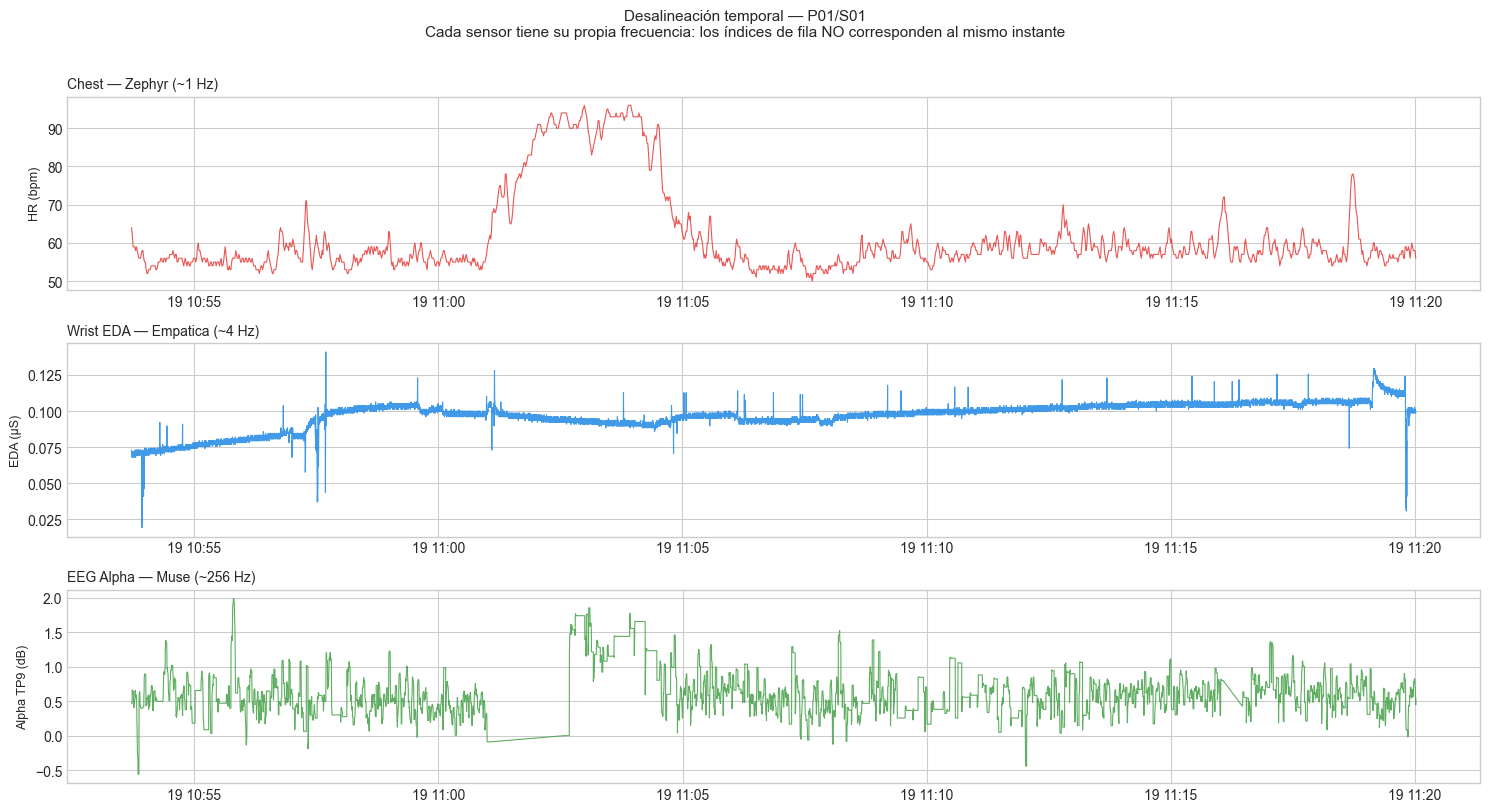

⚠ Fila 100 de chest ≠ fila 100 de EDA ≠ fila 100 de EEG
  → No se pueden concatenar directamente sin sincronizar primero.


In [3]:
# ============================================================
# Paso 2 — Visualizar la desalineación
# Las tres señales en sus propios ejes de tiempo
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=False)

pares = [
    (df_chest_raw, 'hr',  'HR (bpm)',           '#E53935', 'Chest — Zephyr (~1 Hz)'),
    (df_eda_raw,   'eda', 'EDA (µS)',            '#1E88E5', 'Wrist EDA — Empatica (~4 Hz)'),
    (df_eeg_raw,   'TP9', 'Alpha TP9 (dB)',      '#43A047', 'EEG Alpha — Muse (~256 Hz)'),
]

for ax, (df, col, ylabel, color, titulo) in zip(axes, pares):
    if df is not None and col in df.columns and 'datetime' in df.columns:
        ax.plot(df['datetime'], df[col], color=color, linewidth=0.8, alpha=0.85)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(titulo, fontsize=10, loc='left')

plt.suptitle(
    f'Desalineación temporal — P{PID}/S{SES}\n'
    'Cada sensor tiene su propia frecuencia: los índices de fila NO corresponden al mismo instante',
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.show()

print('⚠ Fila 100 de chest ≠ fila 100 de EDA ≠ fila 100 de EEG')
print('  → No se pueden concatenar directamente sin sincronizar primero.')

---
<a id='resampling'></a>
# 🔄 Resampling

**Resampling** significa cambiar la frecuencia de muestreo de una señal.

| Situación | Técnica | Ejemplo |
|---|---|---|
| Reducir Hz | Downsampling | EEG 256 Hz → 1 Hz |
| Aumentar Hz | Upsampling | HR 1 Hz → 4 Hz |

### Downsampling
Se hace **agregando** las muestras que caen en cada ventana temporal (media, max, etc.).

> ⚠️ Riesgo: `aliasing` — perder frecuencias relevantes si se baja demasiado.

### Upsampling
Aumentar frecuencia **crea posiciones temporales vacías (NaN)** que necesitan rellenarse.

> Ahí es donde entra la interpolación.

EDA original :   6313 muestras  (~4.0 Hz)
EDA a 1 Hz   :   1579 muestras
Ratio de reducción: 4.0x


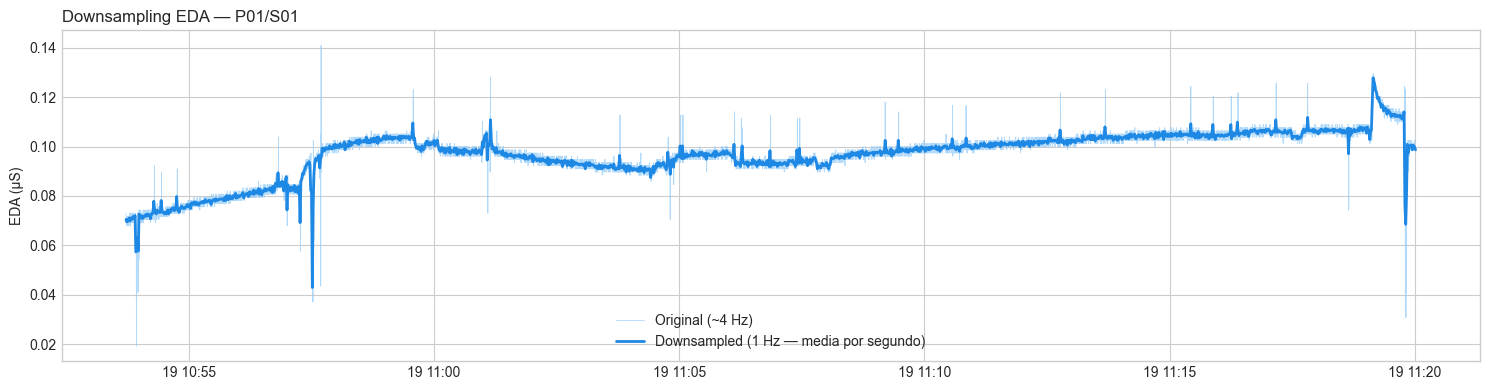

In [ ]:
# ============================================================
# Downsampling: EDA ~4 Hz → 1 Hz
# ============================================================
if df_eda_raw is not None and 'eda' in df_eda_raw.columns and 'datetime' in df_eda_raw.columns:

    eda_ts = df_eda_raw.set_index('datetime')['eda'].sort_index()

    # Downsample: media de las muestras dentro de cada ventana de 1 segundo
    # resample es una función de pandas que permite agrupar datos por intervalos de tiempo (en este caso, cada 1 segundo) y aplicar una función de agregación (en este caso, la media) a los valores dentro de cada intervalo. Esto es útil para reducir la frecuencia de muestreo de una serie temporal, como en este caso con la señal EDA.
    eda_1hz = eda_ts.resample('1s').mean()

    print(f'EDA original : {len(eda_ts):>6} muestras  (~{estimar_hz(df_eda_raw):.1f} Hz)')
    print(f'EDA a 1 Hz   : {len(eda_1hz):>6} muestras')
    print(f'Ratio de reducción: {len(eda_ts)/len(eda_1hz):.1f}x')

    # Visualización
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(eda_ts.index, eda_ts.values,
            color='#90CAF9', linewidth=0.6, alpha=0.7, label=f'Original (~{estimar_hz(df_eda_raw):.0f} Hz)')
    ax.plot(eda_1hz.index, eda_1hz.values,
            color='#1E88E5', linewidth=2.0, label='Downsampled (1 Hz — media por segundo)')
    ax.set_ylabel('EDA (µS)')
    ax.set_title(f'Downsampling EDA — P{PID}/S{SES}', loc='left')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Upsampling: HR ~1 Hz → 4 Hz
# Esto crea NaN en los instantes intermedios
# ============================================================
if df_chest_raw is not None and 'hr' in df_chest_raw.columns and 'datetime' in df_chest_raw.columns:

    hr_ts = df_chest_raw.set_index('datetime')['hr'].sort_index().dropna()

    # Upsample a 250 ms (4 Hz)
    hr_250ms = hr_ts.resample('250ms').asfreq()  # asfreq → NaN en los nuevos instantes

    # Estadísticas de NaN vs originales
    n_nan  = hr_250ms.isna().sum()
    n_orig = hr_250ms.notna().sum()

    print(f'HR original : {len(hr_ts):>6} muestras')
    print(f'HR a 250 ms : {len(hr_250ms):>6} posiciones')
    print(f'  → Valores conocidos : {n_orig}')
    print(f'  → NaN generados     : {n_nan}  ({n_nan/len(hr_250ms)*100:.1f}%)')
    print()
    print('Los NaN son los instantes intermedios — necesitan interpolación.')

    # Mostrar un trozo pequeño
    sample = hr_250ms.head(20).to_frame()
    sample['es_original'] = sample['hr'].notna()
    display(sample)

HR original :   1578 muestras
HR a 250 ms :   6309 posiciones
  → Valores conocidos : 0
  → NaN generados     : 6309  (100.0%)

Los NaN son los instantes intermedios — necesitan interpolación.


,hr,es_original
datetime,,
2021-08-19 10:53:43.250,NaN,False
2021-08-19 10:53:43.500,NaN,False
2021-08-19 10:53:43.750,NaN,False
2021-08-19 10:53:44.000,NaN,False
2021-08-19 10:53:44.250,NaN,False
2021-08-19 10:53:44.500,NaN,False
2021-08-19 10:53:44.750,NaN,False
2021-08-19 10:53:45.000,NaN,False
2021-08-19 10:53:45.250,NaN,False


---
<a id='interpolacion'></a>
# 📈 Interpolación

**Interpolar** es estimar valores intermedios entre puntos conocidos.

Ejemplo con pulso:
```
t=0s → 70 bpm
t=1s → 72 bpm
```
Si queremos 4 Hz, necesitamos estimar `t=0.25, 0.5, 0.75`.

### Tipos comunes

| Método | Descripción | Cuándo usarlo |
|---|---|---|
| **Lineal** | Une puntos con línea recta | Señales suaves, uso general |
| **Spline (cúbica)** | Curvas suaves de orden 3 | Señales fisiológicas continuas |
| **Forward fill** | Mantiene el último valor conocido | Sensores discretos, eventos |

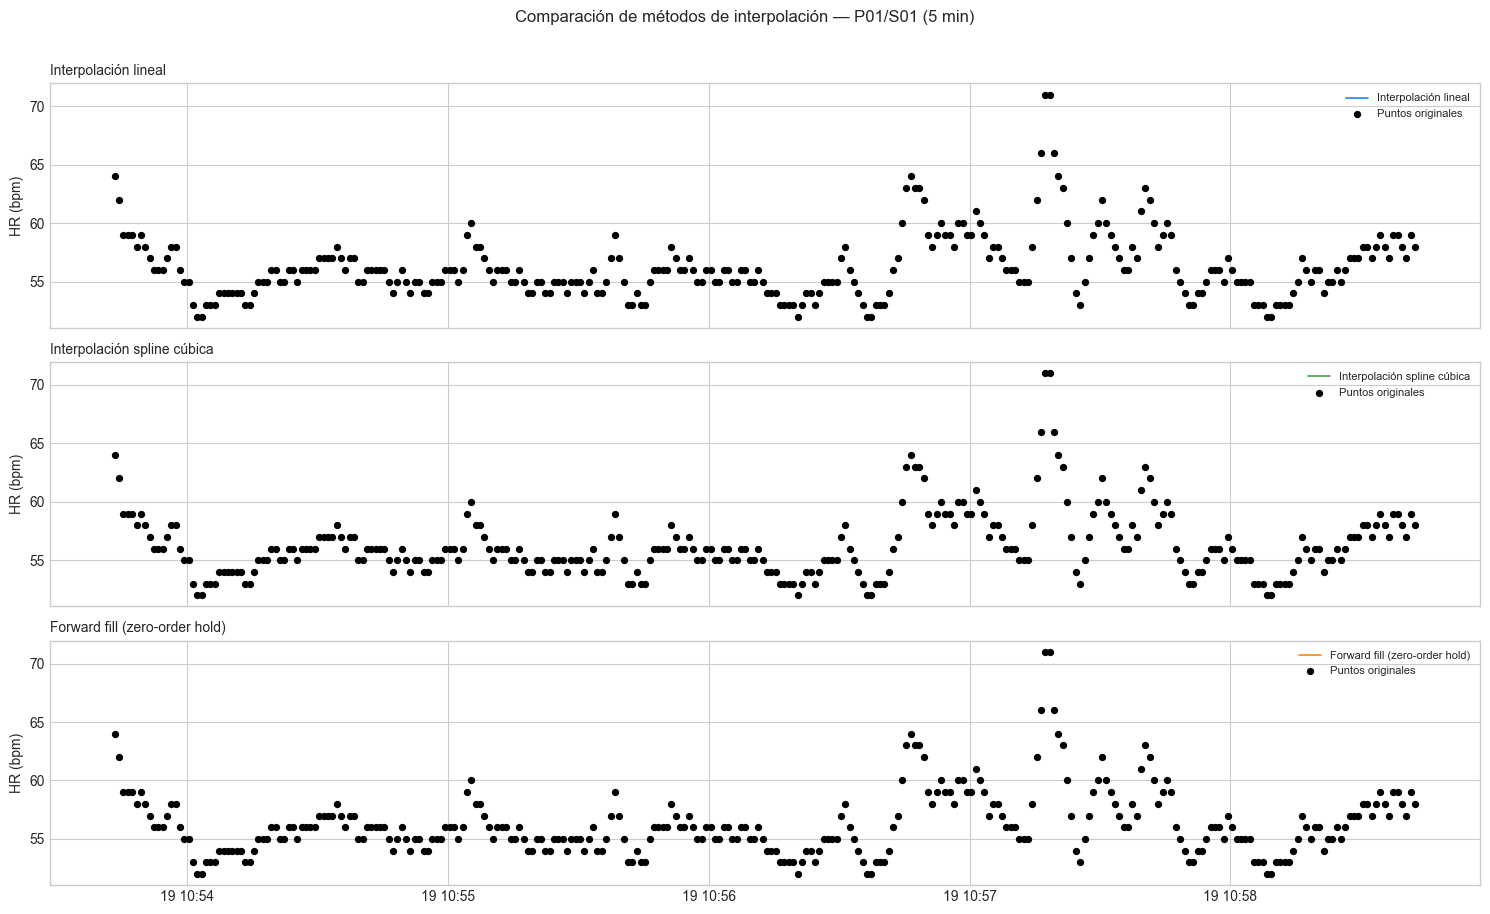

RMSE (en puntos originales) — cuánto se desvía cada método:
  Interpolación lineal               : nan bpm  (debería ser ~0, es exacto en puntos conocidos)
  Interpolación spline cúbica        : nan bpm  (debería ser ~0, es exacto en puntos conocidos)
  Forward fill (zero-order hold)     : nan bpm  (debería ser ~0, es exacto en puntos conocidos)


In [ ]:
# ============================================================
# Comparar los 3 métodos de interpolación sobre HR upsampleado
# ============================================================
if df_chest_raw is not None and 'hr' in df_chest_raw.columns:

    hr_ts = df_chest_raw.set_index('datetime')['hr'].sort_index().dropna()
    hr_up = hr_ts.resample('250ms').asfreq()  # NaN en intermedios

    # Trabajamos con un segmento de 5 minutos para que sea legible
    t0 = hr_up.index[0]
    t1 = t0 + pd.Timedelta(minutes=5)
    hr_seg = hr_up[t0:t1].copy()
    hr_orig_seg = hr_ts[t0:t1]

    # 1. Interpolación lineal
    # interpolate es una función de pandas que permite rellenar los valores NaN en una serie temporal utilizando 
    # diferentes métodos de interpolación. En este caso, con method='linear', se realiza una interpolación lineal 
    # entre los puntos conocidos (no NaN) para estimar los valores en los instantes intermedios donde hay NaN.
    hr_lineal = hr_seg.interpolate(method='linear')

    # 2. Interpolación spline cúbica
    hr_spline = hr_seg.interpolate(method='cubic')

    # 3. Forward fill (zero-order hold)
    # ffill es una función de pandas que permite rellenar los valores NaN en una serie temporal 
    # utilizando el último valor conocido hacia adelante. En este caso, con method='ffill', se 
    # toma el último valor no NaN y se extiende hacia adelante para llenar los NaN hasta que se 
    # encuentre un nuevo valor conocido.
    hr_ffill  = hr_seg.ffill()

    # --- Plot comparativo ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
    metodos = [
        (hr_lineal, '#1E88E5', 'Interpolación lineal'),
        (hr_spline, '#43A047', 'Interpolación spline cúbica'),
        (hr_ffill,  '#FB8C00', 'Forward fill (zero-order hold)'),
    ]

    for ax, (serie, color, titulo) in zip(axes, metodos):
        ax.plot(serie.index, serie.values, color=color, linewidth=1.2, label=titulo)
        ax.scatter(hr_orig_seg.index, hr_orig_seg.values,
                   color='black', s=18, zorder=5, label='Puntos originales')
        ax.set_ylabel('HR (bpm)')
        ax.set_title(titulo, loc='left', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)

    plt.suptitle(f'Comparación de métodos de interpolación — P{PID}/S{SES} (5 min)', y=1.01)
    plt.tight_layout()
    plt.show()

    # Error cuadrático medio respecto a puntos conocidos (en las posiciones originales)
    idx_orig = hr_orig_seg.index
    print('RMSE (en puntos originales) — cuánto se desvía cada método:')
    for serie, _, titulo in metodos:
        vals_pred = serie.reindex(idx_orig)
        rmse = np.sqrt(((vals_pred - hr_orig_seg) ** 2).mean())
        print(f'  {titulo:<35}: {rmse:.4f} bpm  (debería ser ~0, es exacto en puntos conocidos)')

---
<a id='pipeline'></a>
# 🔗 Pipeline completo de sincronización

En pipelines multimodales:

1. Cada sensor tiene su frecuencia
2. Sincronizas por **timestamp** común
3. Haces **resampling** a una frecuencia objetivo
4. Usas **interpolación** para rellenar huecos
5. Obtienes un **tensor alineado** `[tiempo × señales]`

```
chest_hr    (~1 Hz)  ──┐
wrist_eda   (~4 Hz)  ──┤ resample('1s') + interpolate → tensor [T × 3]
eeg_alpha  (~256 Hz) ──┘
```

> La frecuencia objetivo la elige el diseñador del pipeline según la señal más lenta (para no perder información por upsampling excesivo) o un compromiso entre señales.

In [ ]:
# ============================================================
# Pipeline: Chest HR + EDA + EEG alpha → tensor a 1 Hz
# ============================================================

FREQ_OBJETIVO = '1s'   # 1 Hz — dictada por la señal más lenta (chest HR)

def sincronizar_senal(df, col, freq=FREQ_OBJETIVO):
    """Convierte timestamp, indexa por datetime, resamplea e interpola."""
    if df is None or col not in df.columns:
        return None
    ts = df.set_index('datetime')[col].sort_index().dropna()
    resampled = ts.resample(freq).mean()        # downsample o crear slots
    interpolated = resampled.interpolate('linear').ffill().bfill()
    return interpolated

hr_sync  = sincronizar_senal(df_chest_raw, 'hr')
eda_sync = sincronizar_senal(df_eda_raw,   'eda')

# Para EEG usamos el promedio de los 4 canales disponibles
if df_eeg_raw is not None and 'datetime' in df_eeg_raw.columns:
    canales_ok = [c for c in CANALES_EEG if c in df_eeg_raw.columns]
    df_eeg_raw['eeg_mean'] = df_eeg_raw[canales_ok].mean(axis=1)
    eeg_sync = sincronizar_senal(df_eeg_raw, 'eeg_mean')
else:
    eeg_sync = None

# Construir el tensor alineado
# Solo incluimos las señales que se pudieron sincronizar correctamente (no None)
partes = {k: v for k, v in [('hr', hr_sync), ('eda', eda_sync), ('eeg_alpha', eeg_sync)] if v is not None}
tensor = pd.concat(partes, axis=1).dropna()
tensor.index.name = 'tiempo'

print(f'Frecuencia objetivo : {FREQ_OBJETIVO}')
print(f'Tensor alineado     : {tensor.shape[0]} instantes × {tensor.shape[1]} señales')
print(f'Duración            : {(tensor.index[-1] - tensor.index[0]).total_seconds()/60:.1f} min')
print()
display(tensor.head(10))

Frecuencia objetivo : 1s
Tensor alineado     : 1578 instantes × 3 señales
Duración            : 26.3 min



,hr,eda,eeg_alpha
tiempo,,,
2021-08-19 10:53:43,64.0000,0.0705,0.4308
2021-08-19 10:53:44,62.0000,0.0695,0.4114
2021-08-19 10:53:45,59.0000,0.0705,0.2709
2021-08-19 10:53:46,59.0000,0.0698,0.2819
2021-08-19 10:53:47,59.0000,0.0711,0.2949
2021-08-19 10:53:48,58.0000,0.0698,0.1815
2021-08-19 10:53:49,59.0000,0.0711,0.0635
2021-08-19 10:53:50,58.0000,0.0705,0.1135
2021-08-19 10:53:51,57.0000,0.0711,0.0861


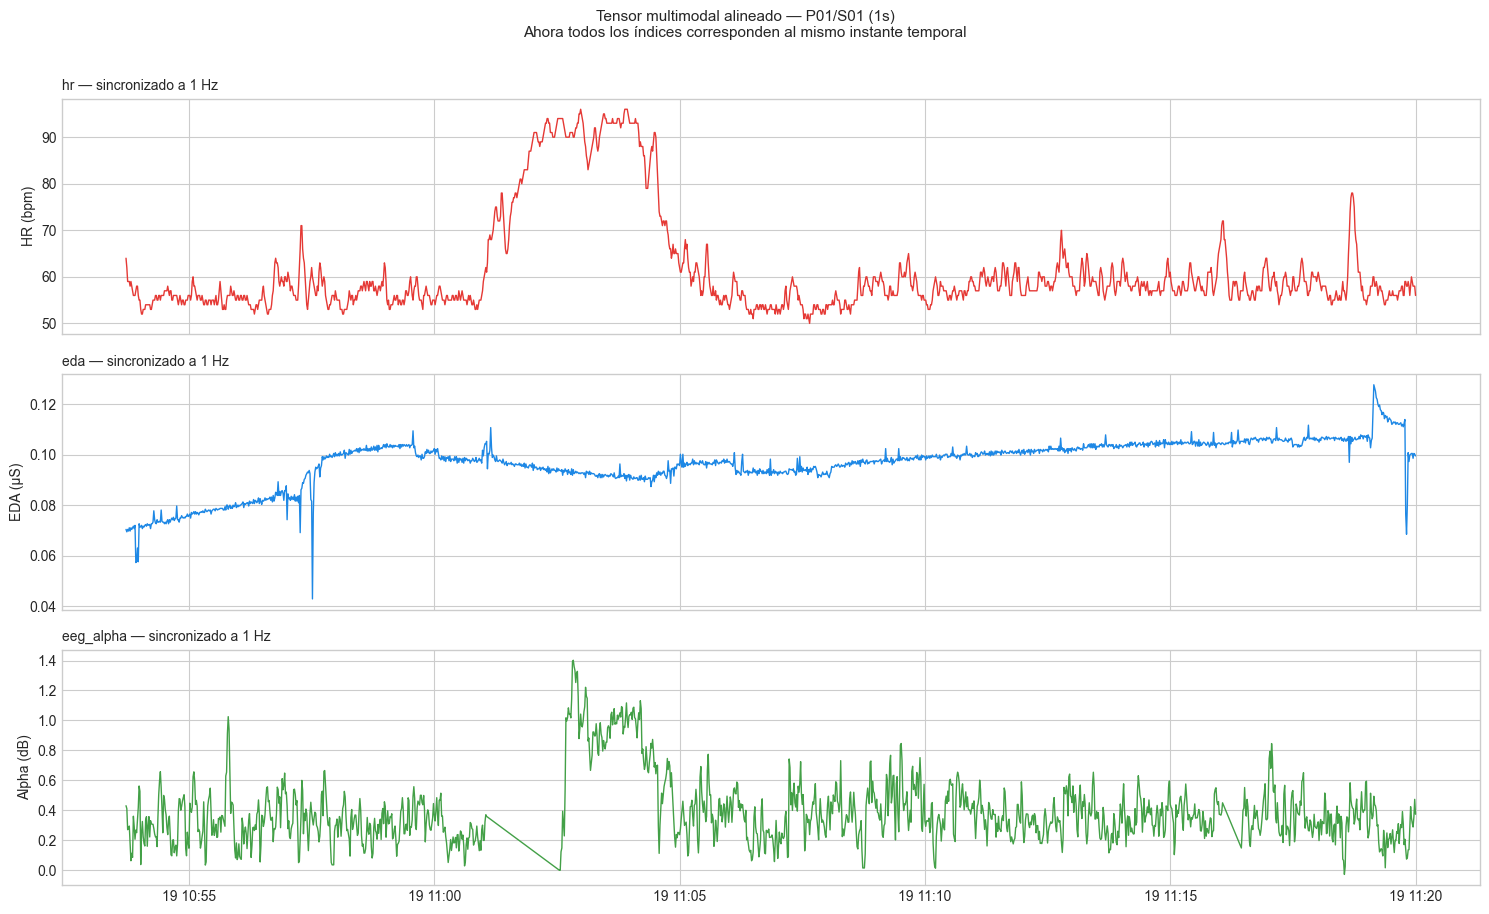

In [8]:
# Visualizar el tensor alineado
if not tensor.empty:
    fig, axes = plt.subplots(len(tensor.columns), 1,
                              figsize=(15, 3 * len(tensor.columns)), sharex=True)
    if len(tensor.columns) == 1:
        axes = [axes]

    colores_senal = {'hr': '#E53935', 'eda': '#1E88E5', 'eeg_alpha': '#43A047'}
    ylabels       = {'hr': 'HR (bpm)', 'eda': 'EDA (µS)', 'eeg_alpha': 'Alpha (dB)'}

    for ax, col in zip(axes, tensor.columns):
        ax.plot(tensor.index, tensor[col],
                color=colores_senal.get(col, 'gray'), linewidth=1.0)
        ax.set_ylabel(ylabels.get(col, col))
        ax.set_title(f'{col} — sincronizado a 1 Hz', loc='left', fontsize=10)

    plt.suptitle(
        f'Tensor multimodal alineado — P{PID}/S{SES} ({FREQ_OBJETIVO})\n'
        'Ahora todos los índices corresponden al mismo instante temporal',
        y=1.01, fontsize=11
    )
    plt.tight_layout()
    plt.show()

---
<a id='norm-global'></a>
# 🎛 Normalización global

Calculas media y desviación estándar usando **todos los datos del dataset** (todos los sujetos):

$$x_{norm} = \frac{x - \mu_{global}}{\sigma_{global}}$$

donde $\mu_{global}$ y $\sigma_{global}$ se calculan sobre todas las filas del dataset (12 sujetos × 3 sesiones × 3 fases).

### ¿Qué hace realmente?
El modelo aprende **diferencias relativas entre personas** — la información absoluta del nivel fisiológico se mantiene.

- Persona A: pulso en reposo 55 bpm
- Persona B: pulso en reposo 85 bpm

Con normalización global, esa diferencia **permanece codificada** en el valor normalizado.

### Ventajas / Riesgos
| ✅ Ventajas | ⚠️ Riesgos |
|---|---|
| Mantiene diferencias inter-sujeto | El modelo puede aprender identidad del sujeto |
| Útil para generalizar a población | Sensible a outliers |
| Necesaria si verá sujetos nuevos | Puede confundir persona con estado |

In [9]:
# ============================================================
# Normalización global sobre el dataset ML agregado
# ============================================================

# Cargar el dataset ML de 108 filas
ml_path = Path('fatigueset_aggregated_features.csv')
if ml_path.exists():
    df_ml = pd.read_csv(ml_path)
else:
    print('Construyendo dataset ML desde cero...')
    dataset = fs_loader.cargar_todo(verbose=False)
    processor = FatigueSetProcessor(intensidad_map)
    df_ml = processor.construir_dataset_ml(
        df_fatiga    = dataset['fatiga'],
        df_chest     = dataset['chest'],
        df_wrist_eda = dataset['wrist'].get('eda'),
        eeg_data     = dataset['eeg'],
        df_nback     = dataset['nback'],
        df_crt       = dataset['crt'],
    )

# Columnas de señal disponibles
# Nota: eeg_alpha_media tiene valores infinitos en el dataset, se excluye
COLS_SENAL = [c for c in ['hr_media', 'eda_media', 'hrv_media']
              if c in df_ml.columns]
print(f'Dataset ML: {df_ml.shape} | Columnas a normalizar: {COLS_SENAL}')

# Normalización global
mu_global    = df_ml[COLS_SENAL].mean()
sigma_global = df_ml[COLS_SENAL].std().replace(0, 1)  # evitar división por cero

df_global_norm = df_ml[COLS_SENAL].copy()
df_global_norm = (df_global_norm - mu_global) / sigma_global

print('\nEstadísticas GLOBALES usadas para normalizar:')
display(pd.DataFrame({'media': mu_global, 'std': sigma_global}).round(3))

print('\nEstadísticas del dataset normalizado (debe ser ~0 media, ~1 std):')
display(df_global_norm.describe().loc[['mean','std']].round(4))

Dataset ML: (108, 19) | Columnas a normalizar: ['hr_media', 'eda_media', 'hrv_media']

Estadísticas GLOBALES usadas para normalizar:


,media,std
hr_media,87.8750,20.1570
eda_media,1.2730,1.7890
hrv_media,69.4640,31.1550



Estadísticas del dataset normalizado (debe ser ~0 media, ~1 std):


,hr_media,eda_media,hrv_media
mean,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000


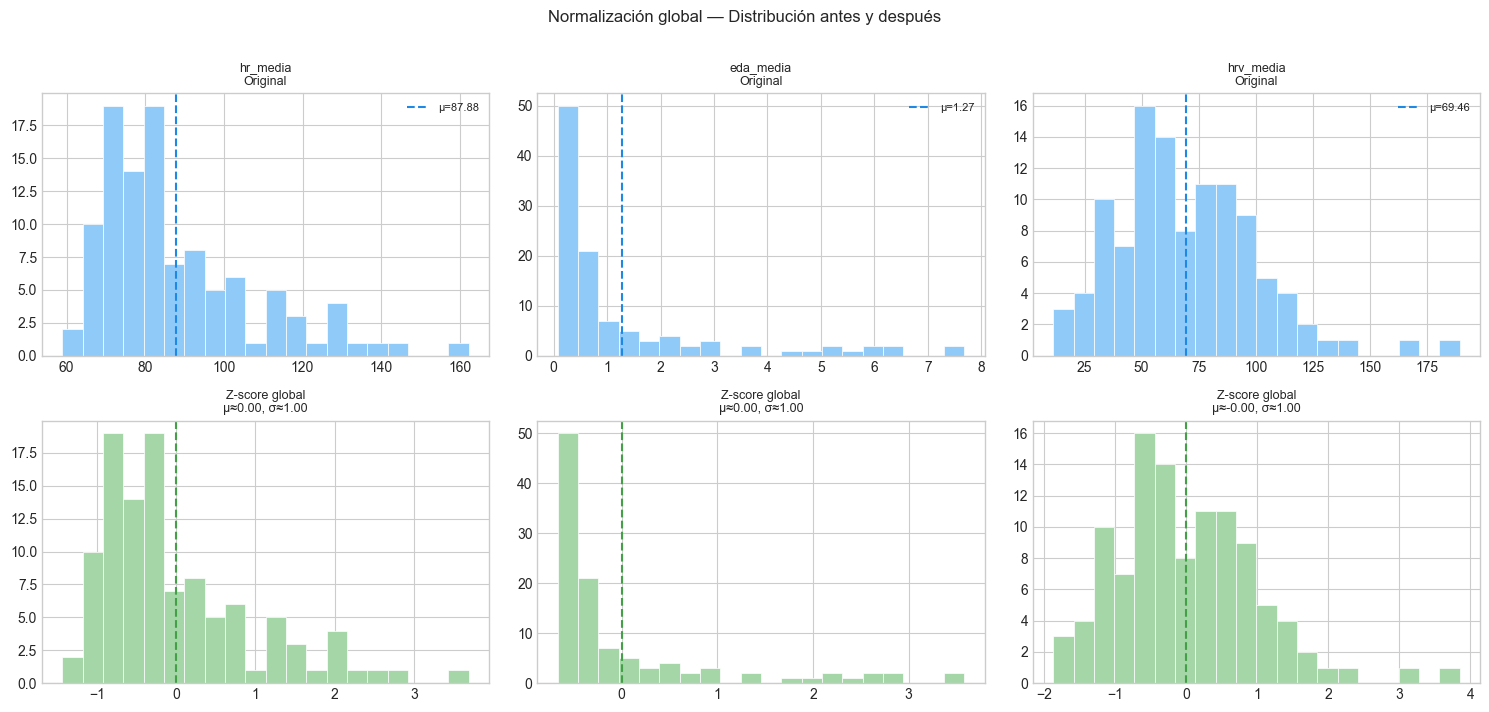

In [10]:
# Visualizar distribución antes y después
if COLS_SENAL:
    fig, axes = plt.subplots(2, len(COLS_SENAL), figsize=(5 * len(COLS_SENAL), 7))
    if len(COLS_SENAL) == 1:
        axes = axes.reshape(2, 1)

    for j, col in enumerate(COLS_SENAL):
        original = df_ml[col].dropna()
        normaliz = df_global_norm[col].dropna()

        axes[0, j].hist(original, bins=20, color='#90CAF9', edgecolor='white', linewidth=0.5)
        axes[0, j].set_title(f'{col}\nOriginal', fontsize=9)
        axes[0, j].axvline(original.mean(), color='#1E88E5', linestyle='--', linewidth=1.5, label=f'μ={original.mean():.2f}')
        axes[0, j].legend(fontsize=8)

        axes[1, j].hist(normaliz, bins=20, color='#A5D6A7', edgecolor='white', linewidth=0.5)
        axes[1, j].set_title(f'Z-score global\nμ≈{normaliz.mean():.2f}, σ≈{normaliz.std():.2f}', fontsize=9)
        axes[1, j].axvline(0, color='#43A047', linestyle='--', linewidth=1.5)

    plt.suptitle('Normalización global — Distribución antes y después', y=1.01)
    plt.tight_layout()
    plt.show()

---
<a id='norm-sujeto'></a>
# 🧍 Normalización por sujeto

Cada persona vive en su propio universo estadístico. Para cada sujeto $i$:

$$x_{norm}^{(i)} = \frac{x - \mu_i}{\sigma_i}$$

donde $\mu_i$ y $\sigma_i$ se calculan **solo con datos de ese sujeto**.

### ¿Qué hace realmente?
Elimina las diferencias basales entre individuos. El modelo aprende **cambios relativos dentro del sujeto**, no niveles absolutos.

- Persona A: 55 bpm → 75 bpm (+20)
- Persona B: 85 bpm → 105 bpm (+20)

Ambos reflejan el mismo **aumento relativo**, aunque sus valores absolutos sean completamente distintos.

### Ventajas / Riesgos
| ✅ Ventajas | ⚠️ Riesgos |
|---|---|
| Ideal para detectar fatiga/estrés (cambios internos) | No generaliza bien a sujetos nuevos sin datos previos |
| Reduce sesgo por identidad del sujeto | Puede ocultar diferencias poblacionales relevantes |
| Mejora modelos personalizados (LOSO) | Necesita suficientes datos por sujeto para estadísticas fiables |

In [11]:
# ============================================================
# Normalización por sujeto
# ============================================================

def normalizar_por_sujeto(df, cols, col_id='participante'):
    """Z-score calculado dentro de cada sujeto."""
    df_norm = df.copy()
    stats = []
    for pid, grupo in df.groupby(col_id):
        mu_i    = grupo[cols].mean()
        sigma_i = grupo[cols].std().replace(0, 1)  # evitar división por cero
        df_norm.loc[grupo.index, cols] = (grupo[cols] - mu_i) / sigma_i
        stats.append({'participante': pid, **{f'mu_{c}': mu_i[c] for c in cols}})
    return df_norm, pd.DataFrame(stats).set_index('participante')

df_sujeto_norm, stats_por_sujeto = normalizar_por_sujeto(df_ml, COLS_SENAL)

print('Media por sujeto ANTES de normalizar — diferencias basales:')
display(df_ml.groupby('participante')[COLS_SENAL].mean().round(2))

print('\nMedia por sujeto DESPUÉS de normalizar por sujeto — debe ser ~0 en todos:')
display(df_sujeto_norm.groupby('participante')[COLS_SENAL].mean().round(4))

Media por sujeto ANTES de normalizar — diferencias basales:


,hr_media,eda_media,hrv_media
participante,,,
1,72.6300,0.4100,81.2800
2,89.1800,0.7900,69.2100
3,100.4500,0.8200,83.7100
4,78.9300,0.3300,74.8700
5,81.0500,0.1900,58.4000
6,81.6400,0.7200,90.4900
7,100.4900,1.4100,46.4100
8,92.2000,0.5700,43.3600
9,107.5400,2.0400,48.9900



Media por sujeto DESPUÉS de normalizar por sujeto — debe ser ~0 en todos:


,hr_media,eda_media,hrv_media
participante,,,
1,-0.0000,0.0000,-0.0000
2,0.0000,0.0000,-0.0000
3,-0.0000,0.0000,0.0000
4,-0.0000,0.0000,0.0000
5,0.0000,0.0000,0.0000
6,0.0000,-0.0000,0.0000
7,0.0000,0.0000,0.0000
8,0.0000,0.0000,-0.0000
9,-0.0000,0.0000,-0.0000


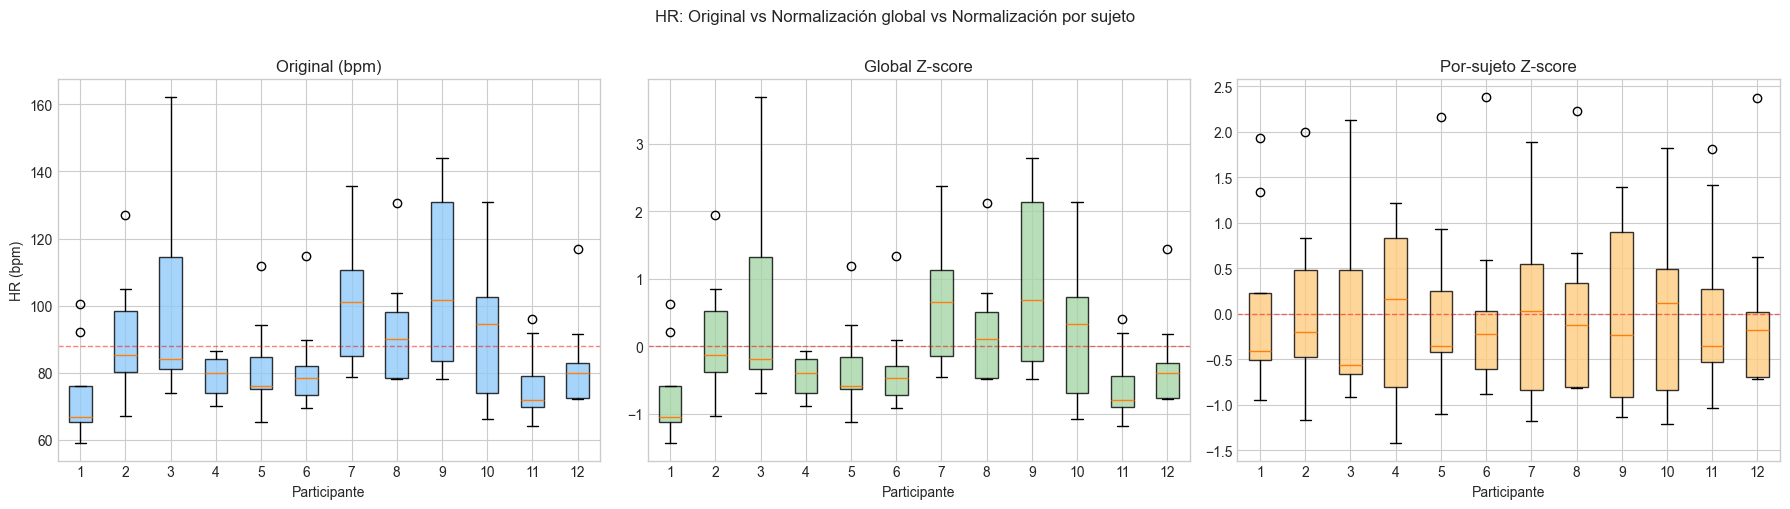

Con normalización por sujeto, cada participante queda centrado en 0,
eliminando las diferencias basales entre personas.


In [12]:
# Comparar global vs por-sujeto: boxplot de HR agrupado por participante
if 'hr_media' in COLS_SENAL:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    participantes_ord = sorted(df_ml['participante'].unique())
    datos_orig   = [df_ml[df_ml['participante'] == p]['hr_media'].dropna().values for p in participantes_ord]
    datos_global = [df_global_norm[df_ml['participante'] == p]['hr_media'].dropna().values for p in participantes_ord]
    datos_sujeto = [df_sujeto_norm[df_sujeto_norm['participante'] == p]['hr_media'].dropna().values for p in participantes_ord]

    for ax, datos, titulo, color in zip(
        axes,
        [datos_orig, datos_global, datos_sujeto],
        ['Original (bpm)', 'Global Z-score', 'Por-sujeto Z-score'],
        ['#90CAF9',         '#A5D6A7',         '#FFCC80']
    ):
        bp = ax.boxplot(datos, patch_artist=True, labels=participantes_ord)
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        ax.set_title(titulo)
        ax.set_xlabel('Participante')
        ax.axhline(0 if 'score' in titulo.lower() else
                   df_ml['hr_media'].mean(), color='red',
                   linestyle='--', linewidth=1, alpha=0.5)

    axes[0].set_ylabel('HR (bpm)')
    plt.suptitle('HR: Original vs Normalización global vs Normalización por sujeto', y=1.01)
    plt.tight_layout()
    plt.show()

print('Con normalización por sujeto, cada participante queda centrado en 0,')
print('eliminando las diferencias basales entre personas.')

---
<a id='leakage'></a>
# 🧠 Data leakage y LOSO — El detalle crítico del TFG

Si haces validación **leave-one-subject-out (LOSO)**:

- Con normalización **global**: si calculas $\mu$ y $\sigma$ con **todos** los datos (incluyendo el sujeto test), el modelo de test ha "visto" indirectamente estadísticas del sujeto test → **data leakage**.
- Con normalización **por sujeto**: debes calcular $\mu_i$ y $\sigma_i$ **solo con datos de entrenamiento**; no puedes usar las estadísticas del sujeto test antes de predecir.

### Regla de oro
> Todo lo que calculas para normalizar (medias, desviaciones, escalers) **solo puede usar datos de entrenamiento**. Los datos de test se normalizan con las estadísticas del train.

```
❌ MAL:   mu = df_todos.mean()   → incluye el sujeto test
✅ BIEN:  mu = df_train.mean()   → solo sujetos de entrenamiento
```

In [13]:
# ============================================================
# Demostración cuantitativa del data leakage
# ============================================================

PID_TEST = '01'   # sujeto que simula el fold de test en LOSO

df_train = df_ml[df_ml['participante'] != PID_TEST].copy()
df_test  = df_ml[df_ml['participante'] == PID_TEST].copy()

# ❌ Estadísticas con TODOS los datos (data leakage)
mu_leak    = df_ml[COLS_SENAL].mean()
sigma_leak = df_ml[COLS_SENAL].std()

# ✅ Estadísticas solo con datos de ENTRENAMIENTO
mu_train    = df_train[COLS_SENAL].mean()
sigma_train = df_train[COLS_SENAL].std()

# Diferencia entre ambas estimaciones
diff_mu    = (mu_leak - mu_train).abs()
diff_sigma = (sigma_leak - sigma_train).abs()

print(f'Comparación: mu calculado con TODOS vs solo TRAIN (sin P{PID_TEST})')
print()
comparacion = pd.DataFrame({
    'mu_todos (leakage)':   mu_leak,
    'mu_train (correcto)':  mu_train,
    '|diferencia|':         diff_mu,
    'sigma_todos':          sigma_leak,
    'sigma_train':          sigma_train,
    '|diff sigma|':         diff_sigma,
}).round(4)
display(comparacion)

print()
print('Cuánto cambia el valor normalizado del sujeto test según qué estadísticas uses:')
test_con_leak  = (df_test[COLS_SENAL] - mu_leak)  / sigma_leak
test_sin_leak  = (df_test[COLS_SENAL] - mu_train) / sigma_train
diff_test = (test_con_leak - test_sin_leak).abs().mean()
print(diff_test.round(4).to_string())

Comparación: mu calculado con TODOS vs solo TRAIN (sin P01)



,mu_todos (leakage),mu_train (correcto),|diferencia|,sigma_todos,sigma_train,|diff sigma|
hr_media,87.8752,87.8752,0.0000,20.1565,20.1565,0.0000
eda_media,1.2725,1.2725,0.0000,1.7890,1.7890,0.0000
hrv_media,69.4644,69.4644,0.0000,31.1552,31.1552,0.0000



Cuánto cambia el valor normalizado del sujeto test según qué estadísticas uses:
hr_media    NaN
eda_media   NaN
hrv_media   NaN


In [14]:
# ============================================================
# Implementación correcta de normalización global en LOSO
# ============================================================

print('Simulación LOSO — normalización global SIN leakage')
print('=' * 55)

resultados_loso = []
for pid_test in sorted(df_ml['participante'].unique()):
    train = df_ml[df_ml['participante'] != pid_test]
    test  = df_ml[df_ml['participante'] == pid_test]

    # Estadísticas calculadas SOLO con el conjunto de entrenamiento
    mu_tr    = train[COLS_SENAL].mean()
    sigma_tr = train[COLS_SENAL].std().replace(0, 1)

    # Normalizar tanto train como test con las mismas estadísticas del train
    train_norm = (train[COLS_SENAL] - mu_tr) / sigma_tr
    test_norm  = (test[COLS_SENAL]  - mu_tr) / sigma_tr

    resultados_loso.append({
        'pid_test':    pid_test,
        'n_train':     len(train),
        'n_test':      len(test),
        **{f'mu_train_{c}': mu_tr[c] for c in COLS_SENAL},
    })

df_loso = pd.DataFrame(resultados_loso).set_index('pid_test')
display(df_loso[['n_train', 'n_test'] + [f'mu_train_{c}' for c in COLS_SENAL]].round(3))

print('\nCada fold tiene sus propias estadísticas de entrenamiento —')
print('el sujeto test nunca contamina el normalizador.')

Simulación LOSO — normalización global SIN leakage


,n_train,n_test,mu_train_hr_media,mu_train_eda_media,mu_train_hrv_media
pid_test,,,,,
1,99,9,89.2610,1.3510,68.3900
2,99,9,87.7560,1.3170,69.4880
3,99,9,86.7320,1.3140,68.1690
4,99,9,88.6890,1.3580,68.9730
5,99,9,88.4960,1.3710,70.4700
6,99,9,88.4420,1.3230,67.5530
7,99,9,86.7280,1.2600,71.5610
8,99,9,87.4820,1.3370,71.8370
9,99,9,86.0880,1.2030,71.3260



Cada fold tiene sus propias estadísticas de entrenamiento —
el sujeto test nunca contamina el normalizador.


---
## Resumen

| Concepto | Qué hace | Herramienta pandas/scipy |
|---|---|---|
| **Sincronización** | Alinear señales por timestamp común | `set_index('datetime')` |
| **Downsampling** | Reducir Hz por agregación | `.resample('1s').mean()` |
| **Upsampling** | Aumentar Hz → crea NaN | `.resample('250ms').asfreq()` |
| **Interpolación lineal** | Rellena NaN con línea recta | `.interpolate('linear')` |
| **Interpolación spline** | Curva suave cúbica | `.interpolate('cubic')` |
| **Forward fill** | Mantiene último valor | `.ffill()` |
| **Norm. global** | Z-score sobre todo el dataset | `(x - x.mean()) / x.std()` |
| **Norm. por sujeto** | Z-score dentro de cada persona | `groupby('participante')` |
| **LOSO sin leakage** | Normalizar con stats solo del train | Calcular μ/σ antes de cada fold |